In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer,StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression,Ridge,Lasso,SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn import metrics

# Boston Regression Probloem

## Attribute Information
### Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

### Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

## EDA

In [4]:
df = pd.read_csv('data/boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.shape

(506, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### Not any Categorical columns

In [7]:
 df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### CRIM, ZN contain outliers , and some of them also skewed.

### No Duplicated

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

### Not any Null Values

In [10]:
df.skew()

CRIM       5.223149
ZN         2.225666
INDUS      0.295022
CHAS       3.405904
NOX        0.729308
RM         0.403612
AGE       -0.598963
DIS        1.011781
RAD        1.004815
TAX        0.669956
PTRATIO   -0.802325
B         -2.890374
LSTAT      0.906460
MEDV       1.108098
dtype: float64

In [11]:
df.CHAS.value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

### Imbalanaced data

In [12]:
def plot_boxplot(df): 
    columns = df.columns
    n_rows = (len(columns) + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(15,25), squeeze=False)

    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        sns.boxplot(x=column,data=df, ax=axes[row,col])

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

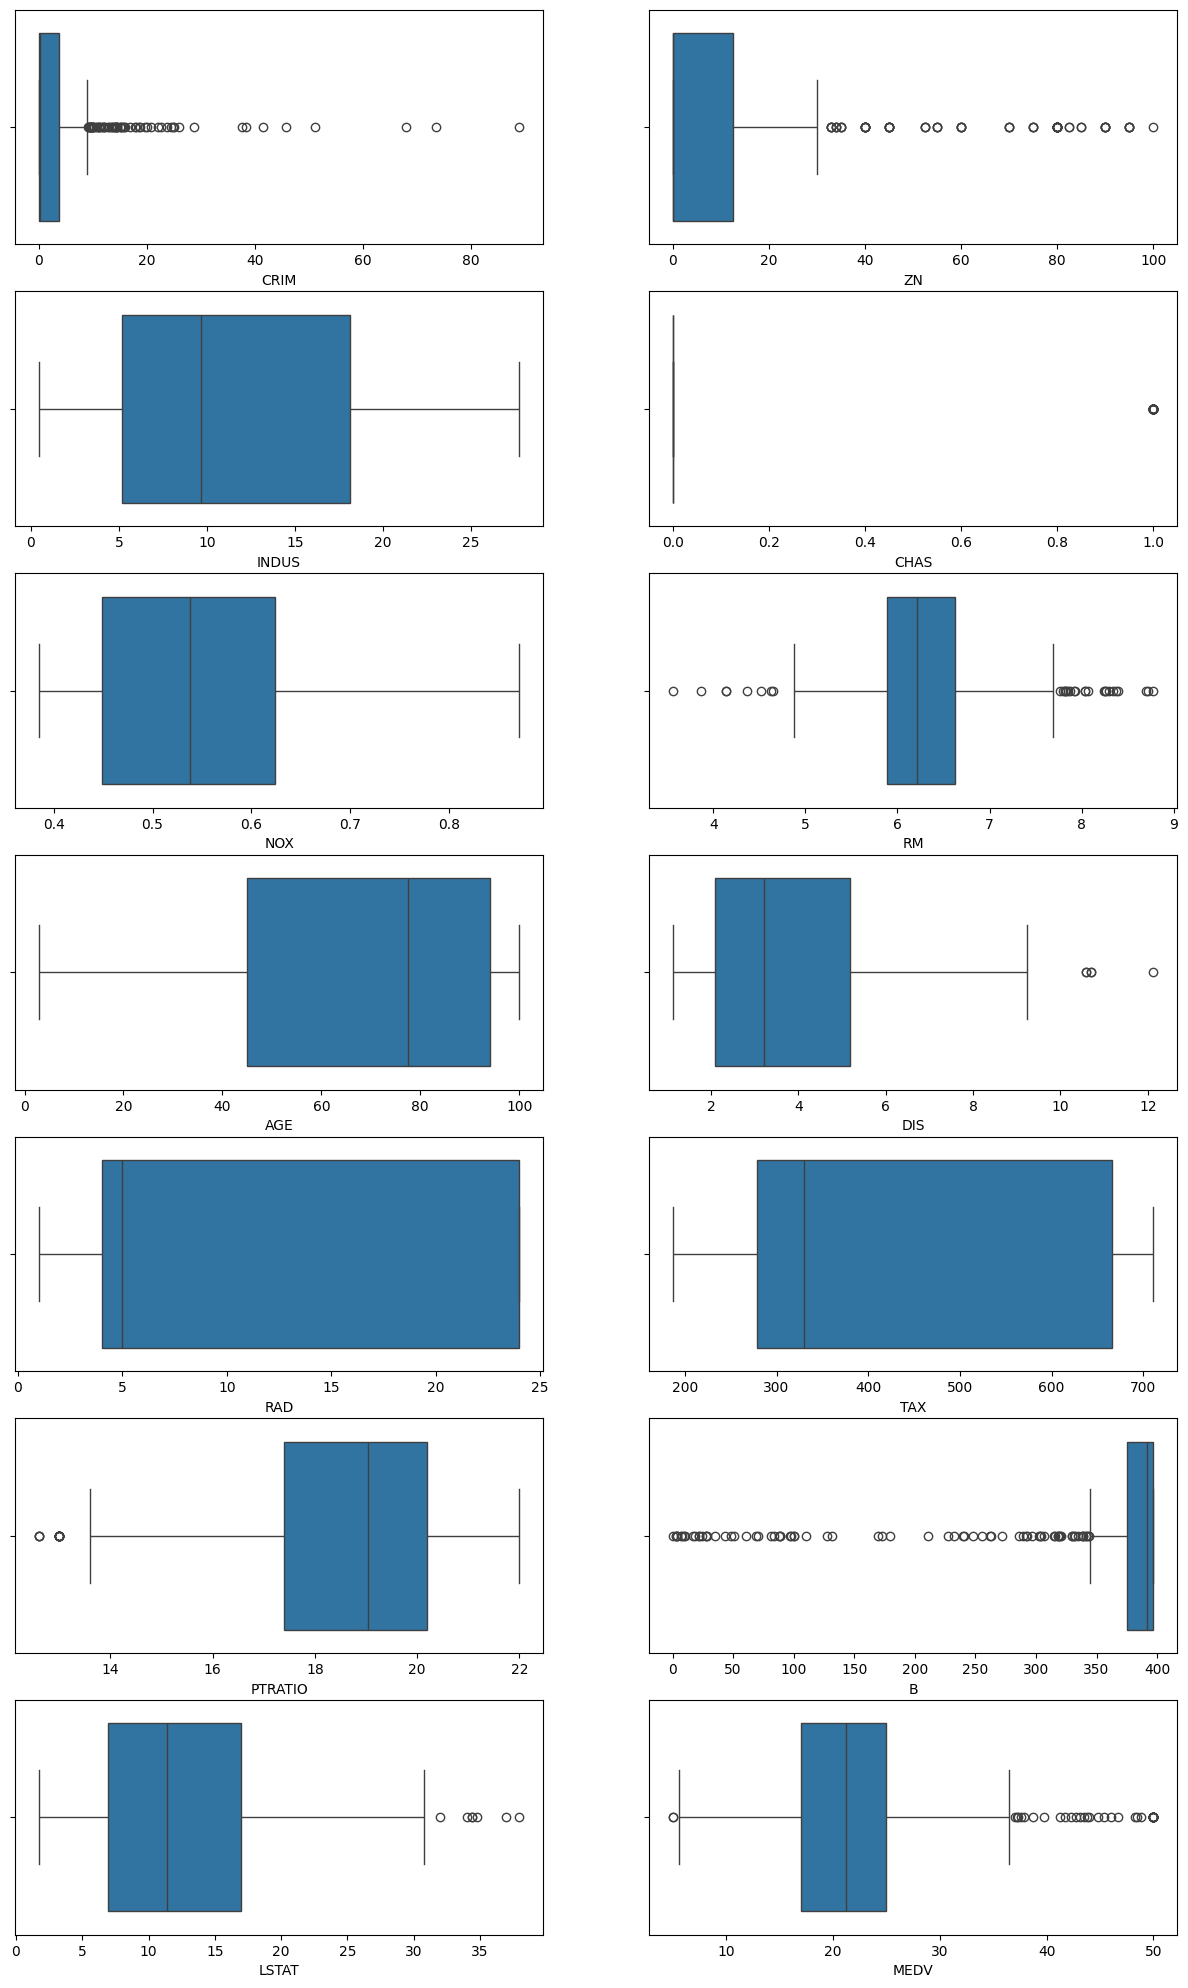

In [13]:
plot_boxplot(df)

### Need to handles the outliers present in CRIM , RM , DIS, PTARTIO, B , LSTAT, and MEDV
### ZN contain many 0 values, we need to fix it before outliers

In [14]:
def plot_histogram(df): 
    columns = df.columns
    n_rows = (len(columns) + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(15,15), squeeze=False)

    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        sns.histplot(df[column], ax=axes[row, col], kde=True)
        axes[row, col].set_title(f'Histogram of {column}')

    plt.tight_layout()
    plt.show()

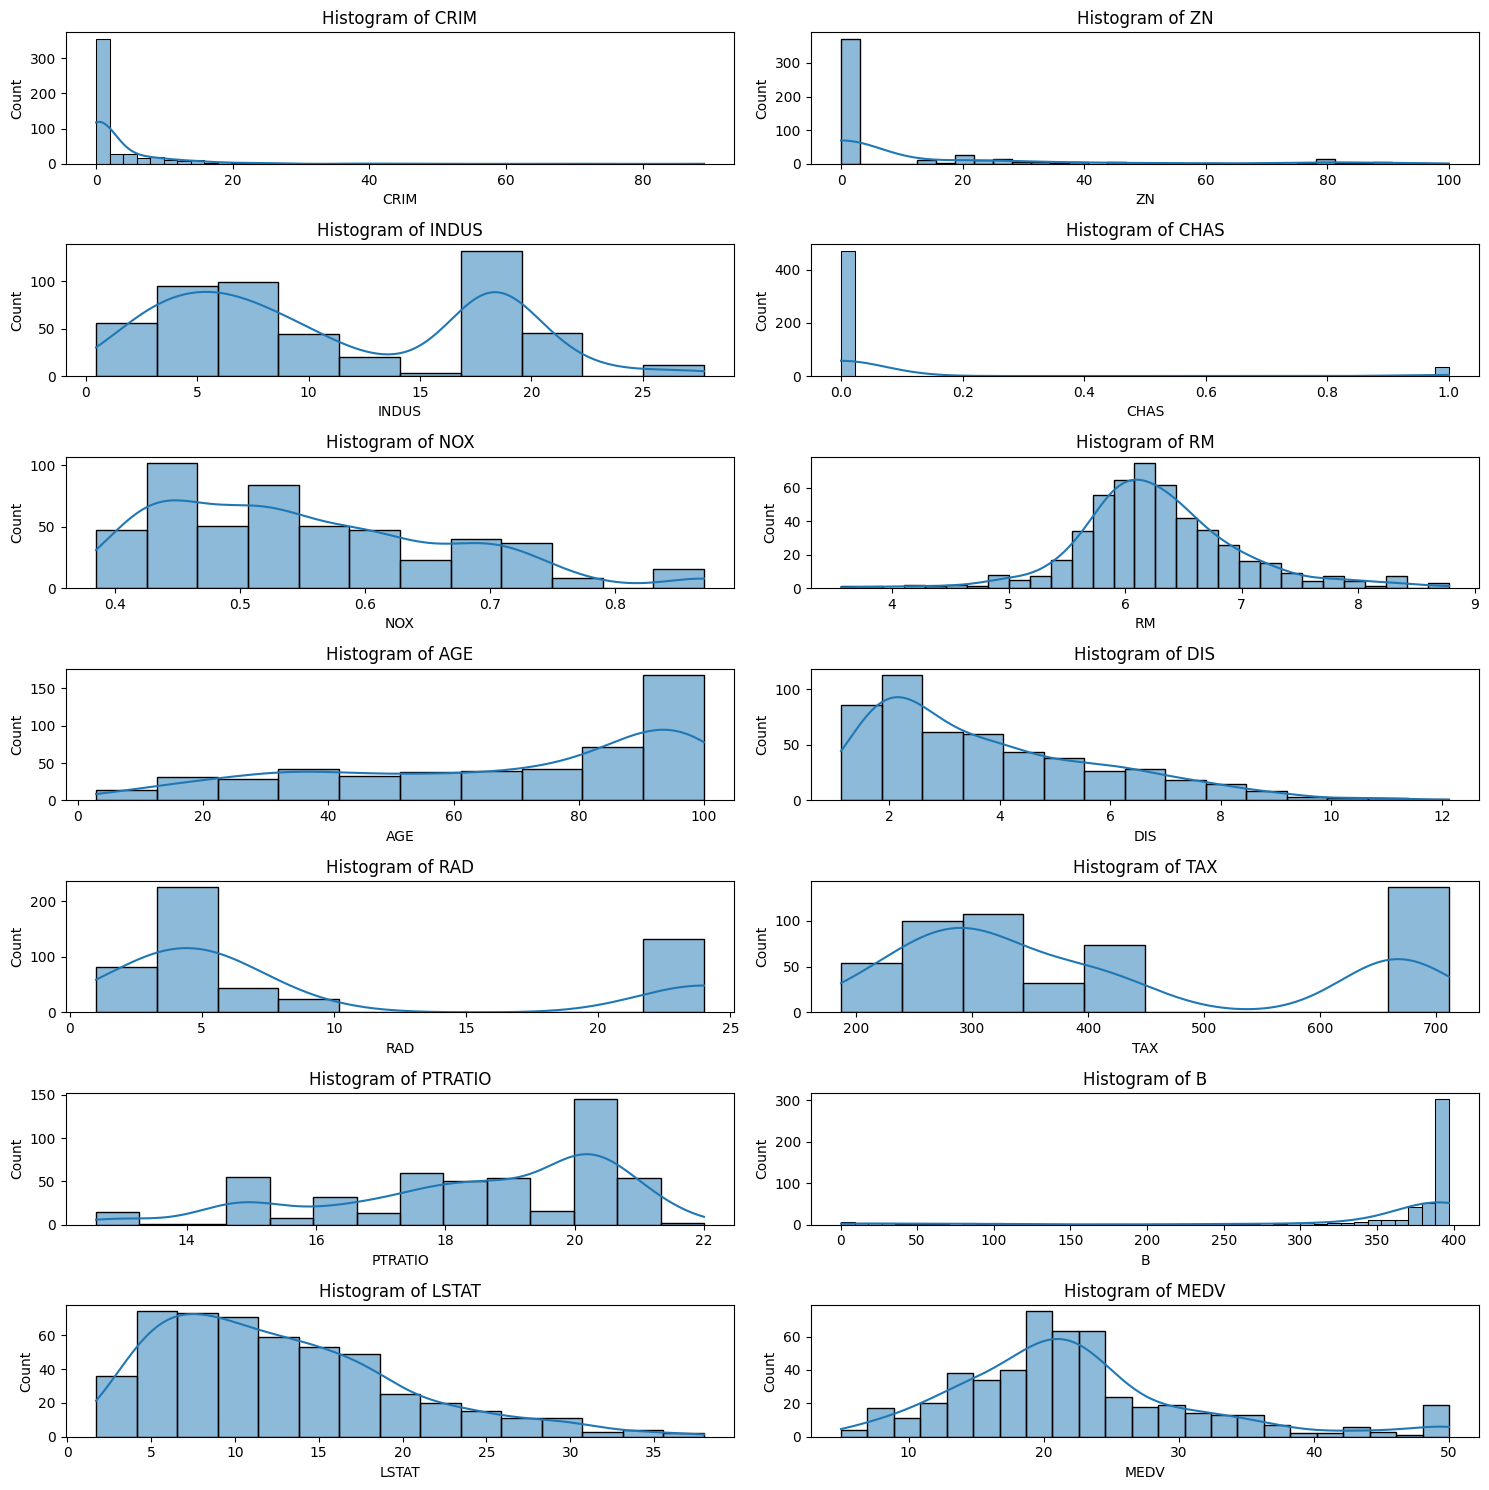

In [15]:
plot_histogram(df)

### CHAS is categorical, RAD is Descrete, RM is perfect distributed.
### ZN is sparse , so do no log transform it. keep as it is or create binary 1/0 to indicate large/small area
### CRIM,DIS needs log transformation, 
### INDUS,age(reasonable) not need any transformation
### NOX slightly skewed no need for transformation.
### TAX keeping it same as not highly skewed
### PTRATIO is also lighlty left skewed no needed
### B Need square Transformation
### LSTAT, MEDV are also lightly skewed no needed

In [16]:
def plot_bi_variate(df):
    columns = df.columns
    n_rows = (len(columns) + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(15,15), squeeze=False)

    for i, column in enumerate(columns):
        row = i // 2
        col = i % 2
        sns.scatterplot(x=column,y='MEDV',data=df, ax=axes[row, col])
        axes[row, col].set_title(f'Histogram of {column}')

    plt.tight_layout()
    plt.show()

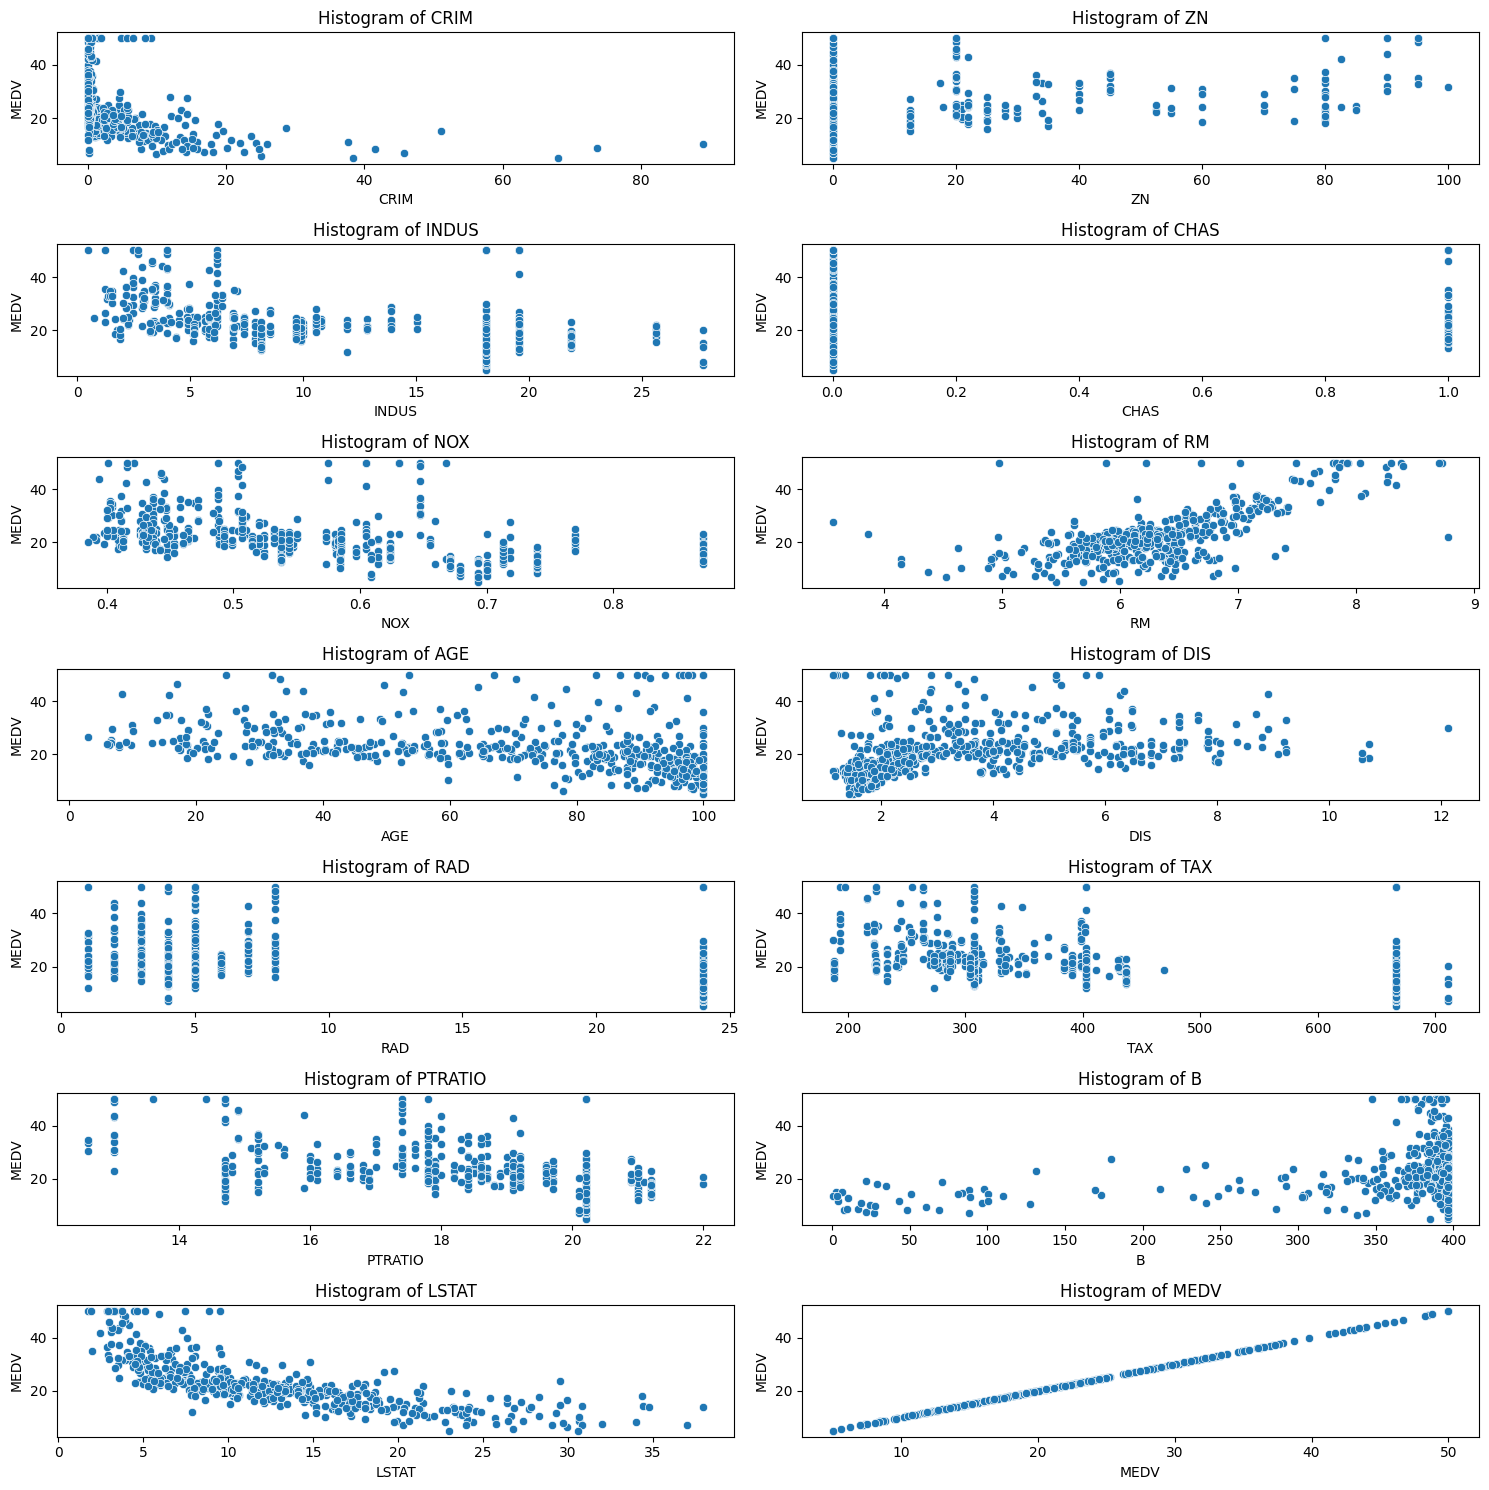

In [17]:
plot_bi_variate(df)

### I can see many feature has non linear relationship, only RAM, LSTAT, NOX,RM ,PTRATIO following linear (weakly). we can use polynomial regression.

In [18]:

def plot_correlation(df, num_cols):
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

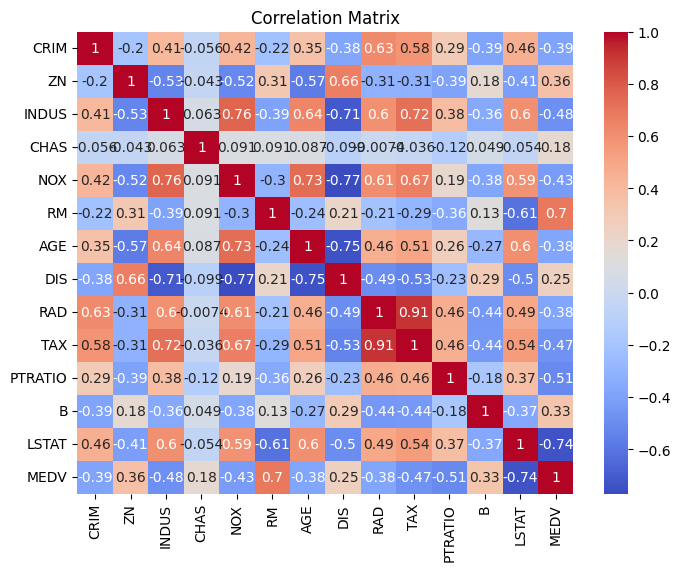

In [19]:
plot_correlation(df,df.columns)

### Many Features has some of weakly correralted with each other , we need to handle correralted features by regularization technique

### Final Conclusion

1. NO Duplicated, No NULL values
2. Need to handles the outliers present in CRIM , RM , DIS, PTARTIO, B , LSTAT.
3. ZN where outliers and also skewed but mostly spared , create binary 1/0 to indicate large/small area
4. Some of them are lighly skewed as no need to transform, but columns CRIM,DIS,B needed transformation
5. Many are non linear so need to polynomial regression to handle it.
6. Weakly Correalted features present also needed the handle it using regularization.
7. MEDV is target feature.

## Feature Engineering

### converting into binary flag, keeping both as needed let model decide

In [20]:
df['ZN_flag'] = (df['ZN'] > 0).astype(int)

In [21]:
df['MEDV'] = np.log1p(df['MEDV'])

In [22]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('MEDV',axis=1),df['MEDV'],random_state=42,test_size=0.2)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((404, 14), (102, 14), (404,), (102,))

### Handling Outliers
- CRIM , RM , DIS, PTARTIO, B , LSTAT, and MEDV
- RM is normally distributed, removing using z-score
- Other with IQR

In [23]:
def IQR_outlier(df):
    df = df.copy()
    
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Cap values
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    return df

In [24]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'ZN_flag'],
      dtype='str')

In [25]:
X_train[['CRIM','DIS','PTRATIO','B','LSTAT']] = IQR_outlier(X_train[['CRIM','DIS','PTRATIO','B','LSTAT']])

In [26]:
from scipy.stats import zscore

def remove_outliers_zscore(df, threshold=3):
    df_numeric = df.select_dtypes(include=['number'])
    
    z_scores = zscore(df_numeric)
    
    # keep rows where all columns are within threshold
    mask = (abs(z_scores) < threshold).all(axis=1)
    
    return df[mask]

In [27]:
X_train[['RM']] = remove_outliers_zscore(X_train[['RM']])

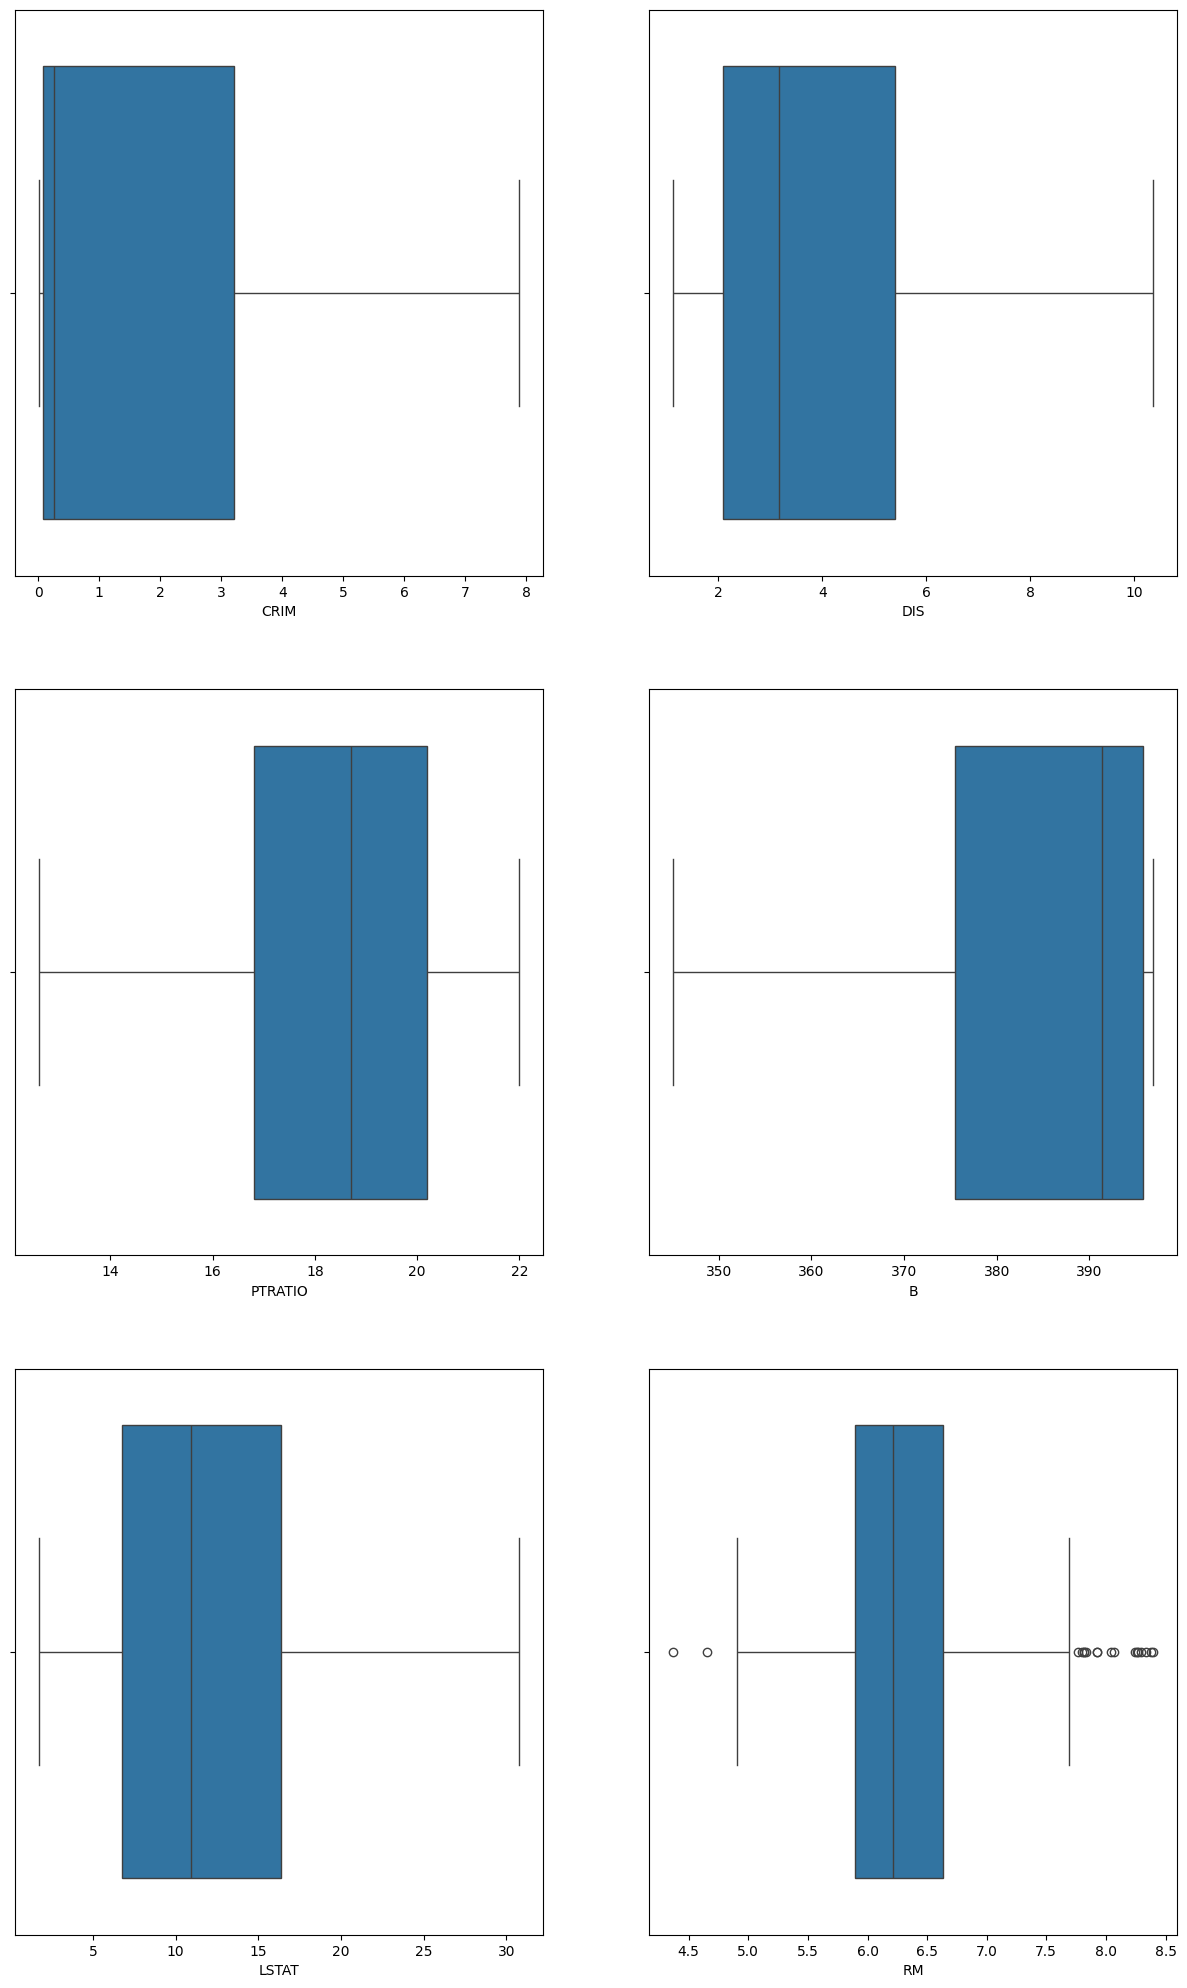

In [28]:
plot_boxplot(X_train[['CRIM','DIS','PTRATIO','B','LSTAT','RM']])

### some outlier present in the RM, which is under the 3 z-score , i wanna keep as it is.High value observation.

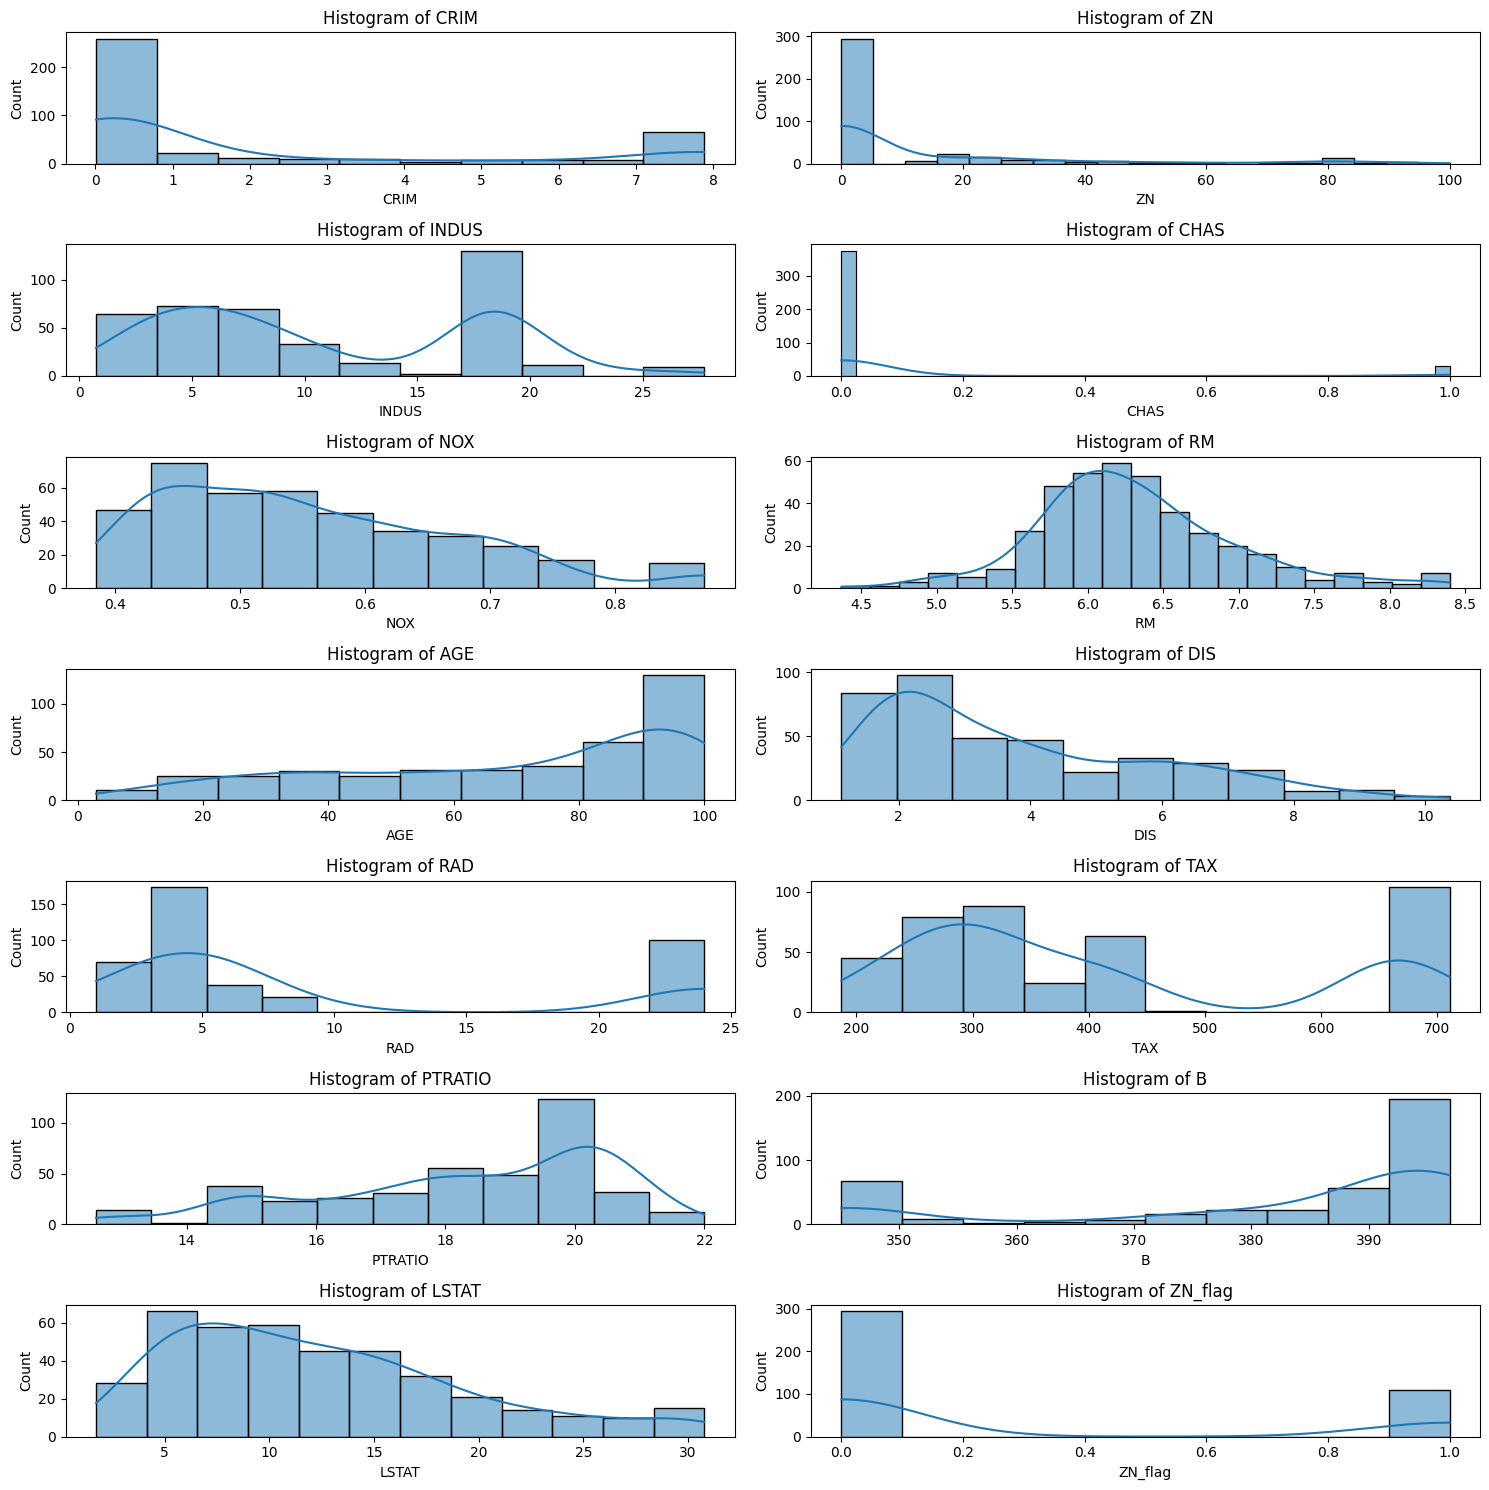

In [29]:
plot_histogram(X_train)

In [30]:
def log_transform(df):
    
    return np.log1p(df['MEDV'])

In [31]:


log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')
sqr_transformer = FunctionTransformer(np.sqrt, feature_names_out='one-to-one')

log_pipeline = Pipeline([
    ('log', log_transformer),
    ('scale', StandardScaler())
])

sqr_pipeline = Pipeline([
    ('sqr', sqr_transformer),
    ('scale', StandardScaler())
])

process = ColumnTransformer(
    transformers=[
        ('log_scaled', log_pipeline, ['CRIM', 'DIS']),
        ('sqr_scaled', sqr_pipeline, ['B']),
        ('std', StandardScaler(), [
            'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
            'RAD', 'TAX', 'PTRATIO', 'LSTAT'
        ])
    ],remainder='passthrough'
)

In [32]:
process.fit(X_train,y_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_scaled', ...), ('sqr_scaled', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [33]:
X_scaled_train = process.transform(X_train)
X_scaled_test = process.transform(X_test)

X_train = pd.DataFrame(X_scaled_train,index=X_train.index,columns=process.get_feature_names_out())
X_test = pd.DataFrame(X_scaled_test,index=X_test.index,columns=process.get_feature_names_out())

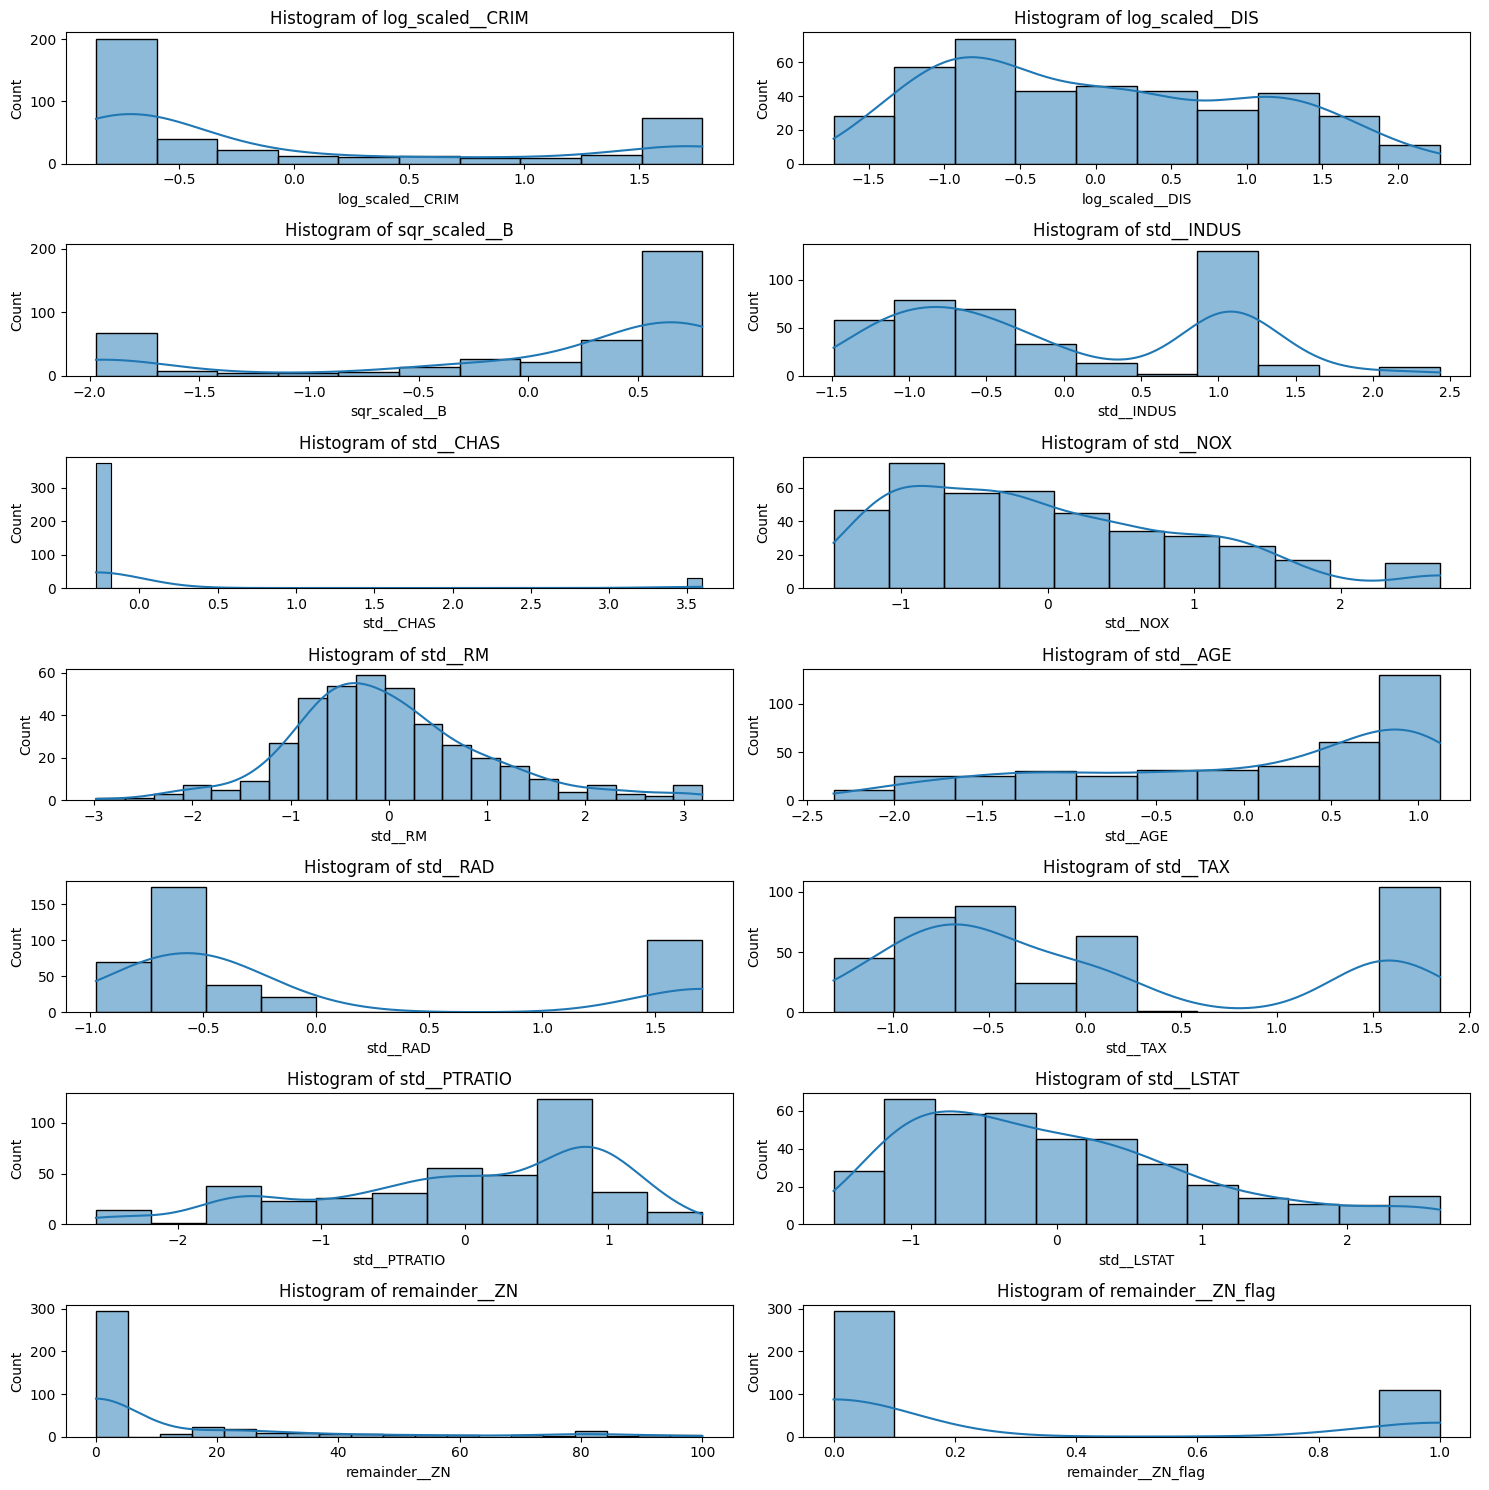

In [34]:
plot_histogram(X_train)

## Model Training

In [35]:
X_train.fillna(X_train.median(),inplace=True)

,log_scaled__CRIM,log_scaled__DIS,sqr_scaled__B,std__INDUS,std__CHAS,std__NOX,std__RM,std__AGE,std__RAD,std__TAX,std__PTRATIO,std__LSTAT,remainder__ZN,remainder__ZN_flag
477,1.774946,-0.833425,-1.726670,1.033237,-0.278089,0.489252,-1.547654,1.028015,1.706891,1.578434,0.845343,1.796032,0.0,0.0
15,-0.281486,0.538616,0.726069,-0.413160,-0.278089,-0.157233,-0.736124,-0.431199,-0.624360,-0.584648,1.204741,-0.565996,0.0,0.0
332,-0.830184,1.326576,-1.032408,-0.715218,-0.278089,-1.008723,-0.434480,-1.618599,-0.974048,-0.602724,-0.637176,-0.657948,35.0,1.0
423,1.655409,-0.895158,-1.970539,1.033237,-0.278089,0.489252,-0.324235,0.591681,1.706891,1.578434,0.845343,1.563278,0.0,0.0
19,-0.210355,0.211435,0.484566,-0.413160,-0.278089,-0.157233,-0.899961,0.033747,-0.624360,-0.584648,1.204741,-0.162267,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.680010,-0.749707,0.728647,-0.352167,-0.278089,-0.310348,-0.733062,0.834884,-0.507797,-0.120700,1.159817,0.898059,0.0,0.0
270,-0.554390,0.508106,0.365094,-0.584520,-0.278089,-0.786706,-0.702438,-0.946216,-0.740922,-1.090773,0.126546,0.084855,20.0,1.0
348,-0.853414,1.808568,0.484047,-1.303361,-0.278089,-1.033391,0.490357,-1.389703,-0.624360,-0.747331,-0.592251,-0.922312,80.0,1.0
435,1.774946,-0.814958,-1.970539,1.033237,-0.278089,1.561057,0.481170,0.931450,1.706891,1.578434,0.845343,1.560404,0.0,0.0


In [42]:
lr = LinearRegression()
m = lr.fit(X_train,y_train)
y_pred = m.predict(X_test)
r2_score(y_test,y_pred)

0.6097916372352401

In [43]:
m.coef_

array([-8.48819465e-02, -9.96465475e-02,  1.30021813e-02,  2.25353828e-02,
        3.11586295e-02, -6.04521087e-02,  8.19154732e-02, -6.09933435e-03,
        9.03829413e-02, -8.08203285e-02, -7.78802218e-02, -2.09574693e-01,
       -1.49442979e-06,  1.58881381e-03])

In [44]:
pipe = Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('model',Ridge(alpha=0.001))
])

p = pipe.fit(X_train,y_train)

y_pred = p.predict(X_test)
r2_score(y_test,y_pred)

-528.2717437831851

In [47]:
p['model'].coef_

array([ 0.00000000e+00,  6.90634628e-02,  2.69341057e-02, -7.86177145e-03,
        1.76737156e-01, -2.05578157e-03, -2.19013122e-02,  1.21450026e-01,
       -7.13594567e-02,  9.91789711e-03,  6.17172476e-02, -1.83222639e-01,
       -5.30827006e-02,  2.28712722e-03, -2.22445880e-01, -3.14638486e-02,
        3.11602318e-02,  4.10626673e-02,  9.80151053e-02,  1.22757571e-01,
       -1.37557327e-01,  3.84939000e-02,  1.69170166e-02, -1.39700205e-01,
        5.62623879e-02,  1.93426968e-02, -2.90081470e-02,  7.72769738e-03,
       -5.22374961e-01,  2.02600856e-01,  6.59196855e-02,  8.84603898e-02,
       -4.72260447e-02,  4.06272421e-01, -4.20433614e-03, -1.06652779e-02,
        2.67757920e-02, -6.81291099e-04, -6.04896240e-02,  2.40145212e-02,
       -2.02131973e-03,  3.88230803e-03, -3.76322229e-02,  1.83245407e-02,
        2.23289799e-03, -4.69030195e-03,  9.27090085e-03, -3.80863807e-02,
       -9.51623464e-02,  8.33368263e-02, -4.83705711e-03,  3.75569658e-02,
       -1.32873623e-03, -

In [104]:
l = Lasso(alpha=0.01)
m = l.fit(X_train,y_train)
y_pred = m.predict(X_test)
r2_score(y_test,y_pred)

0.6534085297463753

In [105]:
print ('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print ('Mean Squared Error:' , metrics.mean_squared_error(y_test, y_pred))
print ('Root Mean Squared Error:' , np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error: 0.13709420055619154
Mean Squared Error: 0.048071379745851205
Root Mean Squared Error: 0.21925186372264024


In [60]:
m.coef_

array([-0.02056036, -0.03136675,  0.00962311, -0.        ,  0.025024  ,
       -0.01474791,  0.08463759, -0.        , -0.        , -0.03363041,
       -0.06081727, -0.20911861, -0.00039435,  0.        ])

In [55]:
r = Ridge(alpha=0.01)
m = r.fit(X_train,y_train)
y_pred = m.predict(X_test)
r2_score(y_test,y_pred)

0.6097537845292295

In [102]:
s = SGDRegressor(loss='squared_error',penalty='elasticnet',max_iter=1000,learning_rate='invscaling',random_state=24)
s.fit(X_train,y_train)
y_pred = s.predict(X_test)
r2_score(y_test,y_pred)

-1.3067171006996993e+23

### Lasso Regression giving us 65% of r2_score, which is highest among all.